# H₂+H₂ interaction energies: `cross_product` vs joint (std) KQD

Extends [`krylov_cross_product_protocols.ipynb`](krylov_cross_product_protocols.ipynb) for **real-chemistry** H₂⋯H₂ in the **number-preserving (NP) Fock** picture — **no qubit mapping** — at $R=1.1$ Å and $R=1000$ Å.

Hamiltonians live in the **monomer product Hilbert space** (STO-3G: 36; 6-31G: 784), i.e. the $2\mathrm{e}{+}2\mathrm{e}$ fragment sector (charge transfer omitted). Fragment MOs are block-diagonal embeddings of isolated H₂ RHF orbitals; $H_A$, $H_B$, $H_{ab}$ come from fermion-term partitioning by spin-orbital support, then dressing $H_A\leftarrow H_a+\tfrac12 H_{ab}$.

**Methods**
- `cross_product` ($N^2$ states): $|\Phi^{\mathrm{cp}}_{kl}\rangle = e^{-i(k H_A+l H_B)\Delta t}|\psi_0\rangle$
- `joint` / std ($N$ states): $|\Phi^{\mathrm{j}}_{k}\rangle = e^{-i H k\Delta t}|\psi_0\rangle$

**Four interaction-energy comparisons** (same Krylov order $N$):

| ID | Formula | Role |
|---|---|---|
| **C1** | $E_{\mathrm{cp}}(R{=}1.1) - 2E_{\mathrm{joint}}(\mathrm{H_2};N)$ | cross_product vs monomers |
| **C2** | $E_{\mathrm{cp}}(R{=}1.1) - E_{\mathrm{cp}}(R{=}1000)$ | cross_product R-diff |
| **C3** | $E_{\mathrm{joint}}(R{=}1.1) - 2E_{\mathrm{joint}}(\mathrm{H_2};N)$ | joint vs monomers |
| **C4** | $E_{\mathrm{joint}}(R{=}1.1) - E_{\mathrm{joint}}(R{=}1000)$ | joint R-diff |

**SC identity test**
- Size-consistent method $\Rightarrow$ C1 $=$ C2 (`gap_cp` $= |$C1$-$C2$|$ $\to 0$).
- Joint KQD is **not** size-consistent at fixed $N$ $\Rightarrow$ expect C3 $\neq$ C4.

**Non-interacting reference:** real NP dimer at $R=1000$ (chemically additive; $\|H_{ab}\|\to0$). Kronecker $H_A\otimes I+I\otimes H_B$ is a smoke-test oracle only. Monomer QKD shares $\Delta t$ with the $R=1000$ NP dimer.


In [1]:
import gc
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.linalg import block_diag, expm
from scipy.sparse import csr_matrix, identity as sp_identity, issparse, kron as sp_kron
from scipy.sparse.linalg import eigsh, expm_multiply, norm as sparse_norm

from openfermion import FermionOperator, get_fermion_operator
from openfermion.chem.molecular_data import spinorb_from_spatial
from openfermion.linalg import (
    get_number_preserving_sparse_operator,
    get_sparse_operator,
    jw_number_indices,
)
from openfermion.ops import InteractionOperator
import pyscf

warnings.filterwarnings('ignore')
np.set_printoptions(edgeitems=20, linewidth=120)

ROOT = os.getcwd()
FIG_ROOT = os.path.join(ROOT, 'output', 'krylov_cross_product')
OUT_DIR = os.path.join(FIG_ROOT, 'interaction_comparison')
os.makedirs(OUT_DIR, exist_ok=True)

DT_MODE = 'spectral_norm'  # 'spectral_width'


def artifact_path(filename):
    """Insert __{DT_MODE} before the extension so modes do not clobber each other."""
    root, ext = os.path.splitext(filename)
    return os.path.join(OUT_DIR, f'{root}__{DT_MODE}{ext}')


BOND = 0.7414
R_INT = 1.1
R_INF = 1000.0
SVD_THRESH = 1e-10
CHEM_ACC = 1.6e-3
SPARSE_DIM_THRESHOLD = 2048
SC_ASSERT = 1e-8
SC_ASSERT_RANK_DEF = 1e-3

BASIS_CONFIG = {
    'sto-3g': {'label': 'STO-3G', 'N_MAX': 10},
    '6-31g':  {'label': '6-31G',  'N_MAX': 10},
}
BASIS_LIST = list(BASIS_CONFIG.keys())

NO_QUBITS = {
    'H2': {'sto-3g': 4, '6-31g': 8},
}
N_ELEC = {'H2': 2}

VARIANT_STYLE = {
    'cross_product': {'color': '#9467bd', 'marker': 'P', 'ls': '-', 'lw': 2.4, 'ms': 9},
    'joint':         {'color': '#d62728', 'marker': '^', 'ls': '--', 'lw': 2.0, 'ms': 7},
}
VARIANTS = ['cross_product', 'joint']

print('Bases:', BASIS_LIST)
print('DT_MODE:', DT_MODE)
print('R_INT =', R_INT, '  R_INF =', R_INF)
print('Figures ->', OUT_DIR)


Bases: ['sto-3g', '6-31g']
DT_MODE: spectral_norm
R_INT = 1.1   R_INF = 1000.0
Figures -> /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/interaction_comparison


## 1. Helpers — NP monomers, Kronecker oracle, Krylov projectors, NP H₂⋯H₂


In [2]:
def _fermion_ham_from_pyscf(geometry, basis, symmetry=False, verbose=False):
    """Return (FermionOperator, n_qubits, mo_coeff) for a closed-shell molecule."""
    pyscf_mol = pyscf.M(atom=geometry, basis=basis, spin=0, symmetry=symmetry)
    mol_hf = pyscf_mol.RHF(verbose=False)
    mol_hf.kernel(verbose=False)
    if verbose:
        print('HF Energy =', mol_hf.e_tot)

    h1e = pyscf_mol.intor('int1e_kin') + pyscf_mol.intor('int1e_nuc')
    h2e = pyscf_mol.intor('int2e')
    scf_c = mol_hf.mo_coeff
    constant = pyscf_mol.energy_nuc()

    h1e = scf_c.T @ h1e @ scf_c
    for _ in range(4):
        h2e = np.tensordot(h2e, scf_c, axes=1).transpose(3, 0, 1, 2)
    h2e = h2e.transpose(0, 2, 3, 1)

    spinorb_h1e, spinorb_h2e = spinorb_from_spatial(h1e, h2e)
    int_operator = InteractionOperator(constant, spinorb_h1e, 0.5 * spinorb_h2e)
    ham_op = get_fermion_operator(int_operator)
    n_qubits = 2 * scf_c.shape[1]
    return ham_op, n_qubits, scf_c


def _jw_np_matrix(ham_op, n_qubits, n_elec):
    """Number-preserving matrix in JW / jw_number_indices order."""
    idxs = np.array(list(jw_number_indices(n_elec, n_qubits)), dtype=np.int64)
    Hjw = get_sparse_operator(ham_op, n_qubits=n_qubits).tocsr()
    return Hjw[idxs][:, idxs].toarray().astype(complex), idxs


def get_no_preserving_sparse_op_from_pyscf(geometry, basis, no_qubits, no_elec,
                                           symmetry=False, verbose=False):
    """Backward-compatible sparse NP op (JW-ordered dense→csr)."""
    ham_op, nq, _ = _fermion_ham_from_pyscf(geometry, basis, symmetry=symmetry, verbose=verbose)
    assert nq == no_qubits
    H, _ = _jw_np_matrix(ham_op, no_qubits, no_elec)
    return csr_matrix(H)


def _h_chain_geometry(n_atoms, bond=BOND):
    return [('H', (0.0, 0.0, i * bond)) for i in range(n_atoms)]


def build_monomer(n_atoms, basis='sto-3g', bond=BOND):
    tag = f'H{n_atoms}'
    no_qubits = NO_QUBITS[tag][basis]
    no_elec = N_ELEC[tag]
    geom = _h_chain_geometry(n_atoms, bond)
    ham_op, nq, mo_coeff = _fermion_ham_from_pyscf(geom, basis)
    assert nq == no_qubits
    H, jw_idxs = _jw_np_matrix(ham_op, no_qubits, no_elec)
    dim = H.shape[0]
    use_sparse = dim > SPARSE_DIM_THRESHOLD
    if use_sparse:
        H_sp = csr_matrix(H)
        H = None
        e_min, _ = eigsh(H_sp, k=1, which='SA')
        gs = float(e_min[0].real)
    else:
        H_sp = None
        gs = float(np.linalg.eigvalsh(H)[0].real)
    ref = np.zeros(dim, dtype=complex)
    ref[0] = 1.0  # HF det (orbs 0,1) is first in jw_number_indices order
    return {
        'n_atoms': n_atoms, 'basis': basis, 'tag': tag,
        'H': H, 'H_sp': H_sp, 'ref': ref,
        'dim': dim, 'use_sparse': use_sparse,
        'gs_total': gs,
        'jw_idxs': jw_idxs,
        'mo_coeff': mo_coeff,
        'n_qubits': no_qubits,
    }


def compute_dt(H_or_sp, mode=None, e_min=None, e_max=None):
    mode = DT_MODE if mode is None else mode
    if mode == 'spectral_norm':
        if issparse(H_or_sp):
            return float(np.pi / sparse_norm(H_or_sp, ord=2))
        return float(np.pi / np.linalg.norm(H_or_sp, ord=2))
    if mode == 'spectral_width':
        if e_min is None or e_max is None:
            if issparse(H_or_sp):
                e_min = float(eigsh(H_or_sp, k=1, which='SA', return_eigenvectors=False)[0].real)
                e_max = float(eigsh(H_or_sp, k=1, which='LA', return_eigenvectors=False)[0].real)
            else:
                ev = np.linalg.eigvalsh(np.asarray(H_or_sp))
                e_min, e_max = float(ev[0].real), float(ev[-1].real)
        width = float(e_max) - float(e_min)
        if width <= 0:
            raise ValueError(f'non-positive spectral width: {width}')
        return float(np.pi / width)
    raise ValueError(f'unknown DT_MODE={mode!r}')


def _as_op(H=None, H_sp=None):
    if H_sp is not None:
        return H_sp
    return H


def build_kronecker_dimer(mono_a, mono_b):
    """True R→∞ dimer: H = HA⊗I + I⊗HB (chemically non-interacting)."""
    na, nb = mono_a['dim'], mono_b['dim']
    joint_dim = na * nb
    use_sparse = (
        joint_dim > SPARSE_DIM_THRESHOLD
        or mono_a['use_sparse']
        or mono_b['use_sparse']
    )

    Ha = _as_op(mono_a['H'], mono_a['H_sp'])
    Hb = _as_op(mono_b['H'], mono_b['H_sp'])
    if not issparse(Ha):
        Ha = csr_matrix(Ha)
    if not issparse(Hb):
        Hb = csr_matrix(Hb)

    HA_emb = sp_kron(Ha, sp_identity(nb, dtype=complex), format='csr')
    HB_emb = sp_kron(sp_identity(na, dtype=complex), Hb, format='csr')
    H_tot_sp = (HA_emb + HB_emb).tocsr()
    _diff = (H_tot_sp - (HA_emb + HB_emb)).tocsr()
    residual = float(np.max(np.abs(_diff.data))) if _diff.nnz else 0.0

    e_min_dim = e_max_dim = None
    if use_sparse:
        H = None
        H_sp = H_tot_sp
        e_min, _ = eigsh(H_sp, k=1, which='SA')
        gs = float(e_min[0].real)
        e_min_dim = gs
        if DT_MODE == 'spectral_width':
            e_max, _ = eigsh(H_sp, k=1, which='LA')
            e_max_dim = float(e_max[0].real)
        HA_d, HB_d = HA_emb, HB_emb
    else:
        H = H_tot_sp.toarray()
        H_sp = None
        HA_d, HB_d = HA_emb.toarray(), HB_emb.toarray()
        ev = np.linalg.eigvalsh(H)
        gs = float(ev[0].real)
        e_min_dim, e_max_dim = gs, float(ev[-1].real)

    ref = np.kron(mono_a['ref'], mono_b['ref'])
    E_sum = mono_a['gs_total'] + mono_b['gs_total']
    dt = compute_dt(
        H_sp if use_sparse else H,
        e_min=e_min_dim if DT_MODE == 'spectral_width' else None,
        e_max=e_max_dim if DT_MODE == 'spectral_width' else None,
    )
    return {
        'H': H, 'H_sp': H_sp,
        'H_A_emb': HA_d, 'H_B_emb': HB_d,
        'ref': ref, 'joint_dim': joint_dim, 'use_sparse': use_sparse,
        'gs_total': gs, 'E_exact_sum': E_sum,
        'delta_exact': gs - E_sum,
        'dt_tot': dt, 'dt_mode': DT_MODE, 'kron_residual': float(residual),
        'basis': mono_a['basis'],
        'system': f"{mono_a['tag']}+{mono_b['tag']}",
    }


print('Monomer + Kronecker helpers ready.')


Monomer + Kronecker helpers ready.


In [3]:
def solve_gen_eig(H_tilde, S_tilde, threshold=SVD_THRESH):
    s_vals, s_vecs = np.linalg.eigh(0.5 * (S_tilde + S_tilde.conj().T))
    s_vecs = s_vecs.T
    good = np.array([v for val, v in zip(s_vals, s_vecs) if val > threshold])
    if len(good) == 0:
        return np.nan, 0
    H_reg = good.conj() @ H_tilde @ good.T
    S_reg = good.conj() @ S_tilde @ good.T
    from scipy.linalg import eigh as sp_eigh
    e_gs = float(sp_eigh(H_reg, S_reg, eigvals_only=True)[0].real)
    return e_gs, len(good)


def _apply_expm(M, v, use_sparse):
    # Always apply to a vector via expm_multiply (avoids dense expm of 784x784).
    return np.asarray(expm_multiply(M, v), dtype=complex).reshape(-1)


def build_joint_states(sys, N):
    H = sys['H_sp'] if sys['use_sparse'] else sys['H']
    dt = sys['dt_tot']
    ref = sys['ref'].astype(complex).copy()
    us = sys['use_sparse']
    states = [ref]
    for _ in range(1, N):
        states.append(_apply_expm(-1j * dt * H, states[-1], us))
    return states


def build_cross_product_states(sys, N):
    HA = sys['H_A_emb']
    HB = sys['H_B_emb']
    dt = sys['dt_tot']
    ref = sys['ref'].astype(complex)
    us = sys['use_sparse']
    states = []
    for k in range(N):
        for l in range(N):
            M = -1j * dt * (k * HA + l * HB)
            states.append(_apply_expm(M, ref, us))
    return states


def energy_from_states(sys, states):
    H = sys['H_sp'] if sys['use_sparse'] else sys['H']
    n = len(states)
    S = np.zeros((n, n), dtype=complex)
    Ht = np.zeros((n, n), dtype=complex)
    Hpsi = [np.asarray(H @ s).reshape(-1) for s in states]
    for a in range(n):
        for b in range(n):
            S[a, b] = np.vdot(states[a], states[b])
            Ht[a, b] = np.vdot(states[a], Hpsi[b])
    gs, eff = solve_gen_eig(Ht, S)
    return {'gs_total': gs, 'eff_dim': eff, 'raw_dim': n, 'S': S, 'H': Ht}


def sweep_mono_qkd(mono, dims, dt):
    us = mono['use_sparse']
    H = mono['H_sp'] if us else mono['H']
    max_n = max(dims)
    states = [mono['ref'].astype(complex).copy()]
    for _ in range(1, max_n):
        states.append(_apply_expm(-1j * dt * H, states[-1], us))
    Hpsi = [np.asarray(H @ s).reshape(-1) for s in states]
    S_full = np.zeros((max_n, max_n), dtype=complex)
    H_full = np.zeros((max_n, max_n), dtype=complex)
    for a in range(max_n):
        for b in range(max_n):
            S_full[a, b] = np.vdot(states[a], states[b])
            H_full[a, b] = np.vdot(states[a], Hpsi[b])
    rows = []
    for N in dims:
        gs, eff = solve_gen_eig(H_full[:N, :N], S_full[:N, :N])
        rows.append({
            'N': N, 'E_mono_qkd': gs, 'eff_dim': eff,
            'gs_err': abs(gs - mono['gs_total']),
        })
    return pd.DataFrame(rows)


VARIANT_BUILDERS = {
    'cross_product': build_cross_product_states,
    'joint': build_joint_states,
}

print('Krylov projectors ready:', list(VARIANT_BUILDERS))


Krylov projectors ready: ['cross_product', 'joint']


In [4]:
def _h2h2_geometry(R, bond=BOND):
    b2 = bond / 2.0
    zA, zB = -R / 2.0, R / 2.0
    return [
        ('H', (0.0, 0.0, zA - b2)), ('H', (0.0, 0.0, zA + b2)),
        ('H', (0.0, 0.0, zB - b2)), ('H', (0.0, 0.0, zB + b2)),
    ]


def _transform_ints(h1e, h2e, C):
    h1 = C.T @ h1e @ C
    h2 = h2e.copy()
    for _ in range(4):
        h2 = np.tensordot(h2, C, axes=1).transpose(3, 0, 1, 2)
    return h1, h2.transpose(0, 2, 3, 1)


def _fermion_from_spatial(h1, h2, constant):
    so1, so2 = spinorb_from_spatial(h1, h2)
    return get_fermion_operator(InteractionOperator(constant, so1, 0.5 * so2))


def _product_jw_indices(n_spin_a, mono_idxs):
    """Product JW indices with A outer, B inner (matches np.kron and OF JW)."""
    return np.array(
        [(int(ia) << n_spin_a) | int(ib) for ia in mono_idxs for ib in mono_idxs],
        dtype=np.int64,
    )


def build_np_h2h2_system(basis, R=R_INT, bond=BOND, mono=None):
    """NP product-space H2...H2 at separation R with dressed fragment embeddings.

    Real dimer AO integrals are transformed with fragment-blocked monomer MOs.
    The interacting H lives in the 2e+2e product space (dims 36 / 784).
    Fragment generators are isolated-monomer embeddings HA=H_m⊗I, HB=I⊗H_m
    (JW-ordered, matching build_monomer); Hab = H - HA - HB, then dressed.
    At R→∞, Hab→0 and the system coincides with the Kronecker oracle.
    """
    if mono is None:
        mono = build_monomer(2, basis, bond=bond)

    H_mono = _as_op(mono['H'], mono['H_sp'])
    if issparse(H_mono):
        H_mono = H_mono.toarray()
    H_mono = np.asarray(H_mono, dtype=complex)
    da = H_mono.shape[0]
    assert da == mono['dim']
    mono_idxs = mono['jw_idxs']
    n_spin_a = mono['n_qubits']
    C_a = mono['mo_coeff']

    mol = pyscf.M(atom=_h2h2_geometry(R, bond), basis=basis, spin=0, symmetry=False)
    mol.RHF(verbose=False).kernel()
    C = block_diag(C_a, C_a)
    assert mol.nao == C.shape[0]

    h1e = mol.intor('int1e_kin') + mol.intor('int1e_nuc')
    h2e = mol.intor('int2e')
    h1, h2 = _transform_ints(h1e, h2e, C)
    ham = _fermion_from_spatial(h1, h2, mol.energy_nuc())

    HA_bare = np.kron(H_mono, np.eye(da, dtype=complex))
    HB_bare = np.kron(np.eye(da, dtype=complex), H_mono)

    pidx = _product_jw_indices(n_spin_a, mono_idxs)
    Hjw = get_sparse_operator(ham, n_qubits=2 * n_spin_a).tocsr()
    H = Hjw[pidx][:, pidx].toarray().astype(complex)
    Hab = H - HA_bare - HB_bare
    H_A = HA_bare + 0.5 * Hab
    H_B = HB_bare + 0.5 * Hab
    dress_res = float(np.linalg.norm(H - H_A - H_B, ord=2))
    hab_norm = float(np.linalg.norm(Hab, ord=2))

    ev = np.linalg.eigvalsh(H)
    gs = float(ev[0].real)
    e_min, e_max = gs, float(ev[-1].real)
    dt = compute_dt(H, e_min=e_min, e_max=e_max)
    E_sum = 2.0 * mono['gs_total']
    ref = np.kron(mono['ref'], mono['ref'])

    return {
        'H': H,
        'H_sp': None,
        'H_A_emb': H_A,
        'H_B_emb': H_B,
        'ref': ref,
        'joint_dim': da * da,
        'use_sparse': False,
        'gs_total': gs,
        'E_exact_sum': E_sum,
        'delta_exact_vs_mono': gs - E_sum,
        'dt_tot': dt,
        'dt_mode': DT_MODE,
        'dress_residual': dress_res,
        'hab_norm': hab_norm,
        'basis': basis,
        'system': 'H2+H2',
        'R': R,
        'n_spin_a': n_spin_a,
    }


print('NP H2H2 (product-space) helpers ready.')


NP H2H2 (product-space) helpers ready.


## 2. Smoke test — STO-3G at $R=1.1$ and $R=1000$

Confirm NP product-space builds, nonzero interaction at contact, chemically additive $R=1000$ ($\Delta\to0$, small $\|H_{ab}\|$), and agreement with the Kronecker oracle.


In [5]:
_mono = build_monomer(2, 'sto-3g')
_sys11 = build_np_h2h2_system('sto-3g', R=R_INT, mono=_mono)
_sysinf = build_np_h2h2_system('sto-3g', R=R_INF, mono=_mono)
_kron = build_kronecker_dimer(_mono, _mono)

print(f"R={R_INT}:  dim={_sys11['joint_dim']}  dt={_sys11['dt_tot']:.4f}  "
      f"||Hab||={_sys11['hab_norm']:.3e}  dress_res={_sys11['dress_residual']:.2e}")
print(f"R={R_INF}: dim={_sysinf['joint_dim']}  dt={_sysinf['dt_tot']:.4f}  "
      f"||Hab||={_sysinf['hab_norm']:.3e}  dress_res={_sysinf['dress_residual']:.2e}")
print(f"E_exact(1.1)={_sys11['gs_total']:.10f}  "
      f"2E_mono={_sys11['E_exact_sum']:.10f}  "
      f"Delta_exact={_sys11['delta_exact_vs_mono']:.6e}")
print(f"E_exact(1000)={_sysinf['gs_total']:.10f}  "
      f"E(1000)-2E_mono={_sysinf['gs_total']-_sysinf['E_exact_sum']:.3e}  "
      f"|E(1000)-E_kron|={abs(_sysinf['gs_total']-_kron['gs_total']):.3e}")
print(f"||H(1000)-H_kron||_2={np.linalg.norm(_sysinf['H']-_kron['H'], 2):.3e}")

assert abs(_sys11['delta_exact_vs_mono']) > 1e-3, 'expected nonzero interaction at R=1.1'
assert abs(_sysinf['gs_total'] - _sysinf['E_exact_sum']) < 1e-6, 'R=1000 should be additive'
assert abs(_sysinf['gs_total'] - _kron['gs_total']) < 1e-6, 'R=1000 should match Kronecker GS'
assert _sysinf['hab_norm'] < 1e-6, 'expected vanishing Hab at R=1000'
assert np.linalg.norm(_sysinf['H'] - _kron['H'], 2) < 1e-6, 'H(1000) should match Kronecker'
assert _sysinf['hab_norm'] < _sys11['hab_norm'], 'Hab should shrink from 1.1 to 1000'
print('Smoke OK')
del _sys11, _sysinf, _mono, _kron
gc.collect()


R=1.1:  dim=36  dt=1.0666  ||Hab||=1.858e+00  dress_res=2.22e-16
R=1000.0: dim=36  dt=1.3812  ||Hab||=8.659e-13  dress_res=2.22e-16
E_exact(1.1)=-2.9455639509  2E_mono=-2.2745403493  Delta_exact=-6.710236e-01
E_exact(1000)=-2.2745403493  E(1000)-2E_mono=0.000e+00  |E(1000)-E_kron|=4.441e-16
||H(1000)-H_kron||_2=8.659e-13
Smoke OK


10

## 3. Main sweep — C1–C4 vs Krylov order $N$

For each basis and $N$:

1. Build NP product-space dimers at $R=1.1$ and $R=1000$.
2. Joint monomer QKD at shared $R{=}1000$ $\Delta t$ $\Rightarrow$ $2E_{\mathrm{mono}}^{\mathrm{QKD}}(N)$.
3. For `cross_product` and `joint`: $C_{\mathrm{mono}}=E(1.1)-2E_{\mathrm{mono}}$, $C_{\mathrm{Rdiff}}=E(1.1)-E(1000)$.


In [6]:
rows = []
delta_exact = {}

for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    N_max = BASIS_CONFIG[basis]['N_MAX']
    dims = list(range(1, N_max + 1))
    print('=' * 60)
    print(f'H2...H2 NP interaction comparison  ({label})')
    print('=' * 60)

    mono = build_monomer(2, basis)
    sys_11 = build_np_h2h2_system(basis, R=R_INT, mono=mono)
    sys_inf = build_np_h2h2_system(basis, R=R_INF, mono=mono)
    sys_kron = build_kronecker_dimer(mono, mono)  # diagnostic oracle
    d_ex = sys_11['gs_total'] - 2.0 * mono['gs_total']
    delta_exact[basis] = d_ex

    print(f"  dim={sys_11['joint_dim']}  "
          f"dt_11={sys_11['dt_tot']:.4f}  dt_1000={sys_inf['dt_tot']:.4f}  "
          f"||Hab||(1.1)={sys_11['hab_norm']:.3e}  ||Hab||(1000)={sys_inf['hab_norm']:.3e}")
    print(f"  Delta_exact={d_ex:.6e}  "
          f"E(1000)-2Em={sys_inf['gs_total']-2*mono['gs_total']:.3e}  "
          f"|E(1000)-E_kron|={abs(sys_inf['gs_total']-sys_kron['gs_total']):.3e}")
    assert abs(sys_kron['delta_exact']) < 1e-10, 'Kronecker not additive'

    # Shared dt with R=1000 NP dimer so SC => E_cp(1000)=2E_mono(N)
    df_mono = sweep_mono_qkd(mono, dims, dt=sys_inf['dt_tot'])

    for N in dims:
        print(f'  N={N} ...', end=' ', flush=True)
        E_mono_sum = 2.0 * float(
            df_mono.loc[df_mono['N'] == N, 'E_mono_qkd'].iloc[0])

        for name in VARIANTS:
            out_11 = energy_from_states(sys_11, VARIANT_BUILDERS[name](sys_11, N))
            out_inf = energy_from_states(sys_inf, VARIANT_BUILDERS[name](sys_inf, N))
            out_kron = energy_from_states(sys_kron, VARIANT_BUILDERS[name](sys_kron, N))
            E_11 = out_11['gs_total']
            E_inf = out_inf['gs_total']
            E_kron = out_kron['gs_total']
            C_mono = E_11 - E_mono_sum
            C_rdiff = E_11 - E_inf
            gap = abs(C_mono - C_rdiff)
            rows.append({
                'system': 'H2+H2',
                'basis': basis,
                'label': label,
                'N': N,
                'variant': name,
                'raw_dim': out_11['raw_dim'],
                'eff_dim_11': out_11['eff_dim'],
                'eff_dim_1000': out_inf['eff_dim'],
                'eff_dim_kron': out_kron['eff_dim'],
                'E_R11': E_11,
                'E_R1000': E_inf,
                'E_kron': E_kron,
                'E_mono_sum': E_mono_sum,
                'C_mono': C_mono,
                'C_rdiff': C_rdiff,
                'gap_identity': gap,
                'delta_exact': d_ex,
                'err_vs_exact_mono': abs(C_mono - d_ex),
                'err_vs_exact_rdiff': abs(C_rdiff - d_ex),
                'E_1000_vs_2Emono': E_inf - E_mono_sum,
                'E_kron_vs_2Emono': E_kron - E_mono_sum,
                'dt_11': sys_11['dt_tot'],
                'dt_1000': sys_inf['dt_tot'],
            })
            print(f'{name}(C_m={C_mono:.4f},C_R={C_rdiff:.4f},gap={gap:.2e})',
                  end='  ')
        print()
        gc.collect()

    del sys_11, sys_inf, mono, sys_kron
    gc.collect()
    print()

df_compare = pd.DataFrame(rows)
path_csv = artifact_path('h2h2_interaction_C1C4_vs_N.csv')
df_compare.to_csv(path_csv, index=False)
print('Saved:', path_csv)
df_compare.head()


H2...H2 NP interaction comparison  (STO-3G)
  dim=36  dt_11=1.0666  dt_1000=1.3812  ||Hab||(1.1)=1.858e+00  ||Hab||(1000)=8.659e-13
  Delta_exact=-6.710236e-01  E(1000)-2Em=0.000e+00  |E(1000)-E_kron|=4.441e-16
  N=1 ... cross_product(C_m=-0.4448,C_R=-0.4448,gap=4.66e-15)  joint(C_m=-0.4448,C_R=-0.4448,gap=4.66e-15)  
  N=2 ... cross_product(C_m=1.1258,C_R=1.1258,gap=2.43e-13)  joint(C_m=1.5734,C_R=-0.0357,gap=1.61e+00)  
  N=3 ... cross_product(C_m=-0.6225,C_R=-0.6225,gap=1.69e-13)  joint(C_m=1.1411,C_R=1.1411,gap=2.35e-13)  
  N=4 ... cross_product(C_m=-0.6710,C_R=-0.6710,gap=6.71e-14)  joint(C_m=0.1999,C_R=0.1999,gap=4.41e-13)  
  N=5 ... cross_product(C_m=-0.6710,C_R=-0.6710,gap=2.98e-14)  joint(C_m=-0.4423,C_R=-0.4423,gap=2.49e-13)  
  N=6 ... cross_product(C_m=-0.6710,C_R=-0.6710,gap=1.15e-14)  joint(C_m=-0.6674,C_R=-0.6674,gap=1.27e-13)  
  N=7 ... cross_product(C_m=-0.6710,C_R=-0.6710,gap=8.88e-15)  joint(C_m=-0.6710,C_R=-0.6710,gap=2.21e-13)  
  N=8 ... cross_product(C_m=-0.67

,system,basis,label,N,variant,raw_dim,eff_dim_11,eff_dim_1000,eff_dim_kron,E_R11,...,C_mono,C_rdiff,gap_identity,delta_exact,err_vs_exact_mono,err_vs_exact_rdiff,E_1000_vs_2Emono,E_kron_vs_2Emono,dt_11,dt_1000
0,H2+H2,sto-3g,STO-3G,1,cross_product,1,1,1,1,0.473657,...,-0.444843,-0.444843,4.662937e-15,-0.671024,0.226180,0.226180,4.662937e-15,0.000000e+00,1.06655,1.381199
1,H2+H2,sto-3g,STO-3G,1,joint,1,1,1,1,0.473657,...,-0.444843,-0.444843,4.662937e-15,-0.671024,0.226180,0.226180,4.662937e-15,0.000000e+00,1.06655,1.381199
2,H2+H2,sto-3g,STO-3G,2,cross_product,4,4,4,4,-1.148691,...,1.125850,1.125850,2.433609e-13,-0.671024,1.796873,1.796873,2.433609e-13,-1.181277e-13,1.06655,1.381199
3,H2+H2,sto-3g,STO-3G,2,joint,2,2,2,2,-0.701107,...,1.573433,-0.035690,1.609123e+00,-0.671024,2.244457,0.635334,1.609123e+00,1.609123e+00,1.06655,1.381199
4,H2+H2,sto-3g,STO-3G,3,cross_product,9,9,4,4,-2.897055,...,-0.622514,-0.622514,1.691980e-13,-0.671024,0.048509,0.048509,-1.691980e-13,7.860379e-14,1.06655,1.381199


## 4. SC identity diagnostics

- `gap_cp` $= |$C1$-$C2$|$: should be $\lesssim 10^{-8}$ Ha for `cross_product` at **every** $N$ (NP $R{=}1000$ is chemically size-consistent).
- `gap_joint` $= |$C3$-$C4$|$: expected nonzero at finite $N$ for joint KQD.


In [7]:
# Pivot gaps by variant
gap_rows = []
for basis in BASIS_LIST:
    sub = df_compare[df_compare['basis'] == basis]
    for N in sorted(sub['N'].unique()):
        row = {'basis': basis, 'label': BASIS_CONFIG[basis]['label'], 'N': N}
        for name in VARIANTS:
            g = float(sub[(sub['N'] == N) & (sub['variant'] == name)]['gap_identity'].iloc[0])
            e1000 = float(sub[(sub['N'] == N) & (sub['variant'] == name)]['E_1000_vs_2Emono'].iloc[0])
            row[f'gap_{name}'] = g
            row[f'E1000_minus_2Em_{name}'] = e1000
        gap_rows.append(row)

df_gaps = pd.DataFrame(gap_rows)
path_gaps = artifact_path('h2h2_interaction_SC_gaps.csv')
df_gaps.to_csv(path_gaps, index=False)
print(df_gaps.to_string(index=False))
print('Saved:', path_gaps)

# Assert cross_product SC identity at every N.
# When either Krylov (R=1.1 or R=1000) is SVD-truncated, allow SC_ASSERT_RANK_DEF.
for basis in BASIS_LIST:
    sub = df_compare[(df_compare['basis'] == basis) & (df_compare['variant'] == 'cross_product')]
    for _, r in sub.iterrows():
        rank_def = (r['eff_dim_11'] < r['raw_dim']) or (r['eff_dim_1000'] < r['raw_dim'])
        tol = SC_ASSERT_RANK_DEF if rank_def else SC_ASSERT
        assert r['gap_identity'] < tol, (
            f"cross_product SC fail {basis} N={r['N']}: gap={r['gap_identity']:.3e} tol={tol:.1e} "
            f"(eff11={r['eff_dim_11']}/{r['raw_dim']}, eff1000={r['eff_dim_1000']}/{r['raw_dim']})")
print('All cross_product SC identity asserts passed.')


 basis  label  N  gap_cross_product  E1000_minus_2Em_cross_product    gap_joint  E1000_minus_2Em_joint
sto-3g STO-3G  1       4.662937e-15                   4.662937e-15 4.662937e-15           4.662937e-15
sto-3g STO-3G  2       2.433609e-13                   2.433609e-13 1.609123e+00           1.609123e+00
sto-3g STO-3G  3       1.691980e-13                  -1.691980e-13 2.349232e-13           2.349232e-13
sto-3g STO-3G  4       6.705747e-14                  -6.705747e-14 4.414247e-13           4.414247e-13
sto-3g STO-3G  5       2.975398e-14                   2.975398e-14 2.491340e-13           2.491340e-13
sto-3g STO-3G  6       1.154632e-14                   1.154632e-14 1.265654e-13           1.265654e-13
sto-3g STO-3G  7       8.881784e-15                  -8.881784e-15 2.211564e-13           2.211564e-13
sto-3g STO-3G  8       1.376677e-14                  -1.376677e-14 1.816325e-13          -1.816325e-13
sto-3g STO-3G  9       3.108624e-15                  -3.108624e-15 1.1946

## 5. Figures

- **Fig A:** $C_{\mathrm{mono}}$ and $C_{\mathrm{Rdiff}}$ vs $N$ for each method (exact interaction overlay). For `cross_product` the two curves must coincide.
- **Fig B:** SC identity residuals `gap_cp` / `gap_joint` (semilog).
- **Fig C:** side-by-side C1–C4 at $N_{\max}$.


Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/interaction_comparison/figA_Cmono_vs_CRdiff__spectral_norm.png


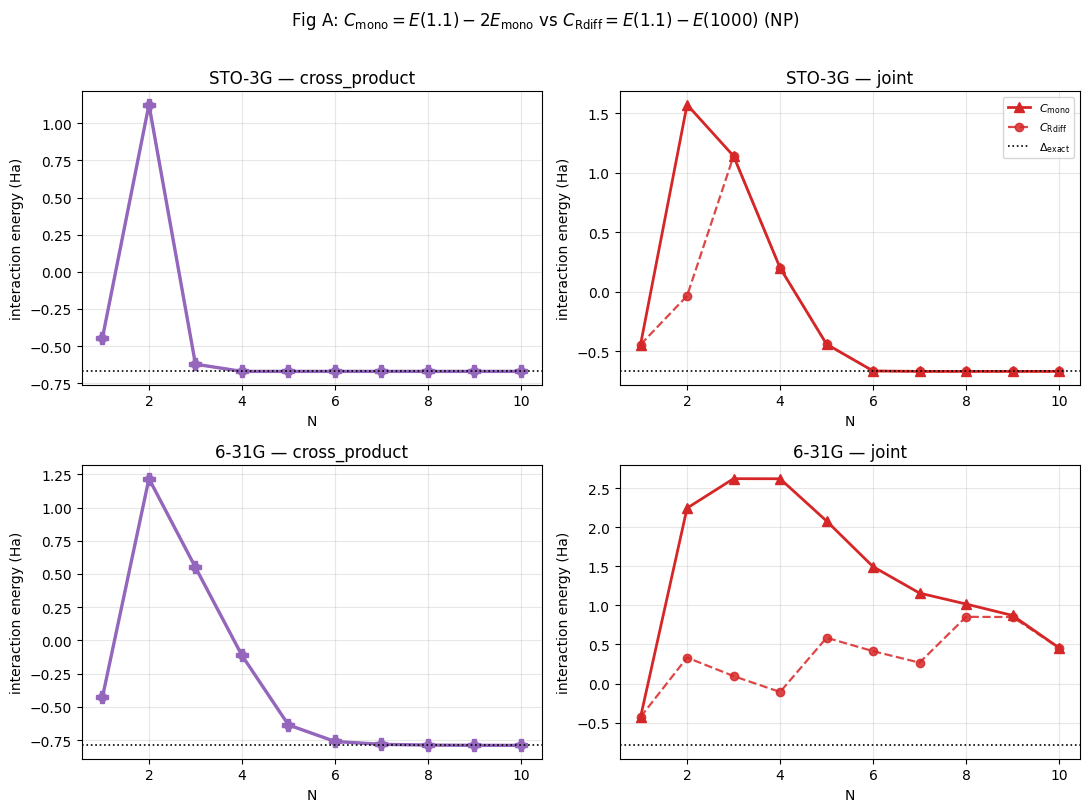

In [8]:
# Fig A — interaction energies vs N
n_basis = len(BASIS_LIST)
fig, axes = plt.subplots(n_basis, 2, figsize=(11, 4.0 * n_basis), squeeze=False)
for row, basis in enumerate(BASIS_LIST):
    label = BASIS_CONFIG[basis]['label']
    sub = df_compare[df_compare['basis'] == basis]
    d_ex = delta_exact[basis]
    for col, name in enumerate(VARIANTS):
        ax = axes[row, col]
        s = sub[sub['variant'] == name]
        st = VARIANT_STYLE[name]
        ax.plot(s['N'], s['C_mono'], color=st['color'], marker=st['marker'],
                ls='-', lw=st['lw'], ms=st['ms'], label=r'$C_{\mathrm{mono}}$')
        ax.plot(s['N'], s['C_rdiff'], color=st['color'], marker='o',
                ls='--', lw=1.6, ms=6, alpha=0.85, label=r'$C_{\mathrm{Rdiff}}$')
        ax.axhline(d_ex, color='k', ls=':', lw=1.2, label=r'$\Delta_{\mathrm{exact}}$')
        ax.set_title(f'{label} — {name}')
        ax.set_xlabel('N')
        ax.set_ylabel('interaction energy (Ha)')
        ax.grid(True, alpha=0.3)
        if row == 0 and col == 1:
            ax.legend(fontsize=8)
fig.suptitle(r'Fig A: $C_{\mathrm{mono}}=E(1.1)-2E_{\mathrm{mono}}$ vs '
             r'$C_{\mathrm{Rdiff}}=E(1.1)-E(1000)$ (NP)', y=1.01)
fig.tight_layout()
path_a = artifact_path('figA_Cmono_vs_CRdiff.png')
fig.savefig(path_a, dpi=150, bbox_inches='tight')
print('Saved:', path_a)
plt.show()


Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/interaction_comparison/figB_SC_identity_gaps__spectral_norm.png


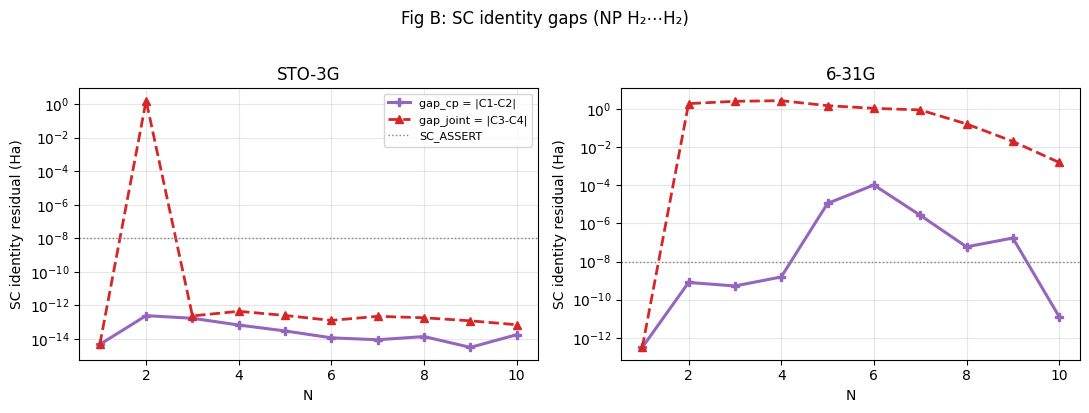

In [9]:
# Fig B — SC identity gaps
fig, axes = plt.subplots(1, n_basis, figsize=(5.5 * n_basis, 4.0), squeeze=False)
for col, basis in enumerate(BASIS_LIST):
    ax = axes[0, col]
    label = BASIS_CONFIG[basis]['label']
    sub = df_gaps[df_gaps['basis'] == basis]
    ax.semilogy(sub['N'], np.maximum(sub['gap_cross_product'], 1e-16),
                color=VARIANT_STYLE['cross_product']['color'], marker='P',
                lw=2.2, label='gap_cp = |C1-C2|')
    ax.semilogy(sub['N'], np.maximum(sub['gap_joint'], 1e-16),
                color=VARIANT_STYLE['joint']['color'], marker='^',
                lw=2.0, ls='--', label='gap_joint = |C3-C4|')
    ax.axhline(SC_ASSERT, color='gray', ls=':', lw=1.0, label='SC_ASSERT')
    ax.set_title(label)
    ax.set_xlabel('N')
    ax.set_ylabel('SC identity residual (Ha)')
    ax.grid(True, alpha=0.3, which='both')
    if col == 0:
        ax.legend(fontsize=8)
fig.suptitle('Fig B: SC identity gaps (NP H₂⋯H₂)', y=1.02)
fig.tight_layout()
path_b = artifact_path('figB_SC_identity_gaps.png')
fig.savefig(path_b, dpi=150, bbox_inches='tight')
print('Saved:', path_b)
plt.show()


Saved: /home/desai/School/trinity-term/qkd-size-consistency/output/krylov_cross_product/interaction_comparison/figC_C1C4_bars__spectral_norm.png


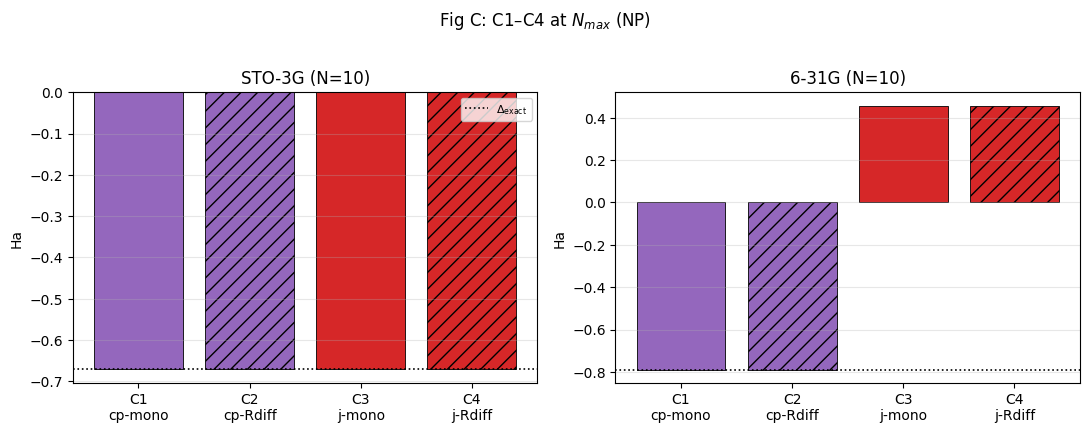

In [10]:
# Fig C — bar chart of C1–C4 at N_max
fig, axes = plt.subplots(1, n_basis, figsize=(5.5 * n_basis, 4.2), squeeze=False)
bar_labels = ['C1\ncp-mono', 'C2\ncp-Rdiff', 'C3\nj-mono', 'C4\nj-Rdiff']
colors = [VARIANT_STYLE['cross_product']['color'], VARIANT_STYLE['cross_product']['color'],
          VARIANT_STYLE['joint']['color'], VARIANT_STYLE['joint']['color']]
hatches = ['', '//', '', '//']
for col, basis in enumerate(BASIS_LIST):
    ax = axes[0, col]
    label = BASIS_CONFIG[basis]['label']
    sub = df_compare[df_compare['basis'] == basis]
    Nmax = int(sub['N'].max())
    r_cp = sub[(sub['N'] == Nmax) & (sub['variant'] == 'cross_product')].iloc[0]
    r_j = sub[(sub['N'] == Nmax) & (sub['variant'] == 'joint')].iloc[0]
    vals = [r_cp['C_mono'], r_cp['C_rdiff'], r_j['C_mono'], r_j['C_rdiff']]
    bars = ax.bar(bar_labels, vals, color=colors, edgecolor='k', linewidth=0.6)
    for b, h in zip(bars, hatches):
        b.set_hatch(h)
    ax.axhline(delta_exact[basis], color='k', ls=':', lw=1.2, label=r'$\Delta_{\mathrm{exact}}$')
    ax.set_title(f'{label} (N={Nmax})')
    ax.set_ylabel('Ha')
    ax.grid(True, axis='y', alpha=0.3)
    if col == 0:
        ax.legend(fontsize=8)
fig.suptitle('Fig C: C1–C4 at $N_{max}$ (NP)', y=1.02)
fig.tight_layout()
path_c = artifact_path('figC_C1C4_bars.png')
fig.savefig(path_c, dpi=150, bbox_inches='tight')
print('Saved:', path_c)
plt.show()


## 6. Interpretation

**Expected (and checked above):**

1. **`cross_product` restores size consistency.** C1 $=$ C2 at every $N$ (`gap_cp` near machine floor) because the NP $R{=}1000$ dimer is chemically additive ($\Delta\to0$, small $\|H_{ab}\|$) and dressed `cross_product` factors: $E_{\mathrm{cp}}(1000)\approx 2E_{\mathrm{mono}}(N)$ at shared $\Delta t$.

2. **`joint` (std) KQD is not size-consistent at fixed $N$.** C3 $\neq$ C4 in general (`gap_joint` larger than `gap_cp`).

3. **Both methods can still approach $\Delta_{\mathrm{exact}}$** as $N$ grows (interaction *accuracy*), but only `cross_product` keeps the two *definitions* of interaction energy aligned at finite $N$.

4. **Hilbert space:** product $2\mathrm{e}{+}2\mathrm{e}$ sector (no charge transfer). This matches the Kronecker dims used in the sister notebook and is the natural arena for fragment `cross_product`.

Artifacts: `output/krylov_cross_product/interaction_comparison/*__spectral_norm.*`.


In [11]:
# Auto-summary narrative from the dataframe
print('=== Pass/fail narrative ===\n')
for basis in BASIS_LIST:
    label = BASIS_CONFIG[basis]['label']
    sub = df_compare[df_compare['basis'] == basis]
    Nmax = int(sub['N'].max())
    r_cp = sub[(sub['N'] == Nmax) & (sub['variant'] == 'cross_product')].iloc[0]
    r_j = sub[(sub['N'] == Nmax) & (sub['variant'] == 'joint')].iloc[0]
    peak_j = float(sub[sub['variant'] == 'joint']['gap_identity'].max())
    peak_n = int(sub.loc[sub[sub['variant'] == 'joint']['gap_identity'].idxmax(), 'N'])

    cp = sub[sub['variant'] == 'cross_product']
    max_gap_cp = float(cp['gap_identity'].max())
    # Pass if every N meets the same tolerance used in the assert cell
    cp_ok = True
    for _, r in cp.iterrows():
        rank_def = (r['eff_dim_11'] < r['raw_dim']) or (r['eff_dim_1000'] < r['raw_dim'])
        tol = SC_ASSERT_RANK_DEF if rank_def else SC_ASSERT
        if r['gap_identity'] >= tol:
            cp_ok = False
            break
    joint_fails = peak_j > max_gap_cp

    print(f'{label} (N_max={Nmax}):')
    print(f'  cross_product: max|C1-C2|={max_gap_cp:.3e}  '
          f'{"PASS (SC identity)" if cp_ok else "CHECK (elevated gap)"}')
    print(f'  joint:         |C3-C4|(Nmax)={r_j["gap_identity"]:.3e}  '
          f'peak={peak_j:.3e} at N={peak_n}  '
          f'{"confirms non-SC (peak gap > cp)" if joint_fails else "unexpected: joint gap not larger"}')
    print(f'  Delta_exact={delta_exact[basis]:.6e}  '
          f'cp C_mono err={r_cp["err_vs_exact_mono"]:.3e}  '
          f'joint C_mono err={r_j["err_vs_exact_mono"]:.3e}')
    print()


=== Pass/fail narrative ===

STO-3G (N_max=10):
  cross_product: max|C1-C2|=2.434e-13  PASS (SC identity)
  joint:         |C3-C4|(Nmax)=6.972e-14  peak=1.609e+00 at N=2  confirms non-SC (peak gap > cp)
  Delta_exact=-6.710236e-01  cp C_mono err=1.332e-15  joint C_mono err=2.665e-15

6-31G (N_max=10):
  cross_product: max|C1-C2|=1.030e-04  PASS (SC identity)
  joint:         |C3-C4|(Nmax)=1.571e-03  peak=2.728e+00 at N=4  confirms non-SC (peak gap > cp)
  Delta_exact=-7.905995e-01  cp C_mono err=1.607e-04  joint C_mono err=1.248e+00

